In [1]:
#!/usr/bin/env python
# coding: utf-8
#
# optimize_1192k_oh_h2o.py
#
# Fit R22/R26 parameters to experimental OH data at 1192 K using the
# trained OH surrogate (result_1192k_oh_gelu_train.pt), then predict the
# H2O time history with the optimized parameters and compare to experiment.

import os
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


## Config — must match nn_toy_1192k_oh_gelu_train.py exactly

In [ ]:
YAML_FILE   = 'chem_cti_toy_model_og.yaml'
IDX_R22     = 21
IDX_R26     = 25
INPUT_DIM   = 4
PARAM_NAMES = ['lnA_R22', 'Ea_R22', 'lnA_R26', 'Ea_R26']
LN_F        = 10
SIGMA_E     = 5000.0
HIDDEN_DIM  = 32
LOG_EPS     = 1e-12

# Zhang Eq. 8 hyperparameters
LAMBDA      = 4.0
NOISE_FLOOR = 1e-12
SIGMA_OB_LN = 0.05

T_INITIAL  = 1192
P_INITIAL  = 1.95 * ct.one_atm
INITIAL_X  = {'H2O2': 2216e-6, 'H2O': 1364e-6, 'O2': 682e-6,
               'AR':   1.0 - (2216 + 1364 + 682) * 1e-6}

# Fixed-step grid for H2O profile (matches training)
DT_SIM   = 1e-6
N_STEPS  = 1000
T_SIM    = np.linspace(DT_SIM, DT_SIM * N_STEPS, N_STEPS)  # 1 µs … 1 ms

# Fine grid for OH profile (dense near peak, sparser afterwards)
T_OH = np.concatenate([
    np.linspace(1e-7, 2e-4, 600),          # 0.1 µs … 0.2 ms — captures peak
    np.linspace(2e-4 + 5e-6, 1e-3, 200),   # 0.2 ms … 1 ms
])

RESULT_PATH = 'result_1192k_oh_relu_4pts_train.pt'
H2O_CSV     = 'hong_1192K_h2o.csv'
OH_CSV      = 'hong_1192K_oh.csv'
OUT_PREFIX  = 'opt_1192k_oh_h2o'


## Nominal rate constants

In [20]:
_gas = ct.Solution(YAML_FILE)
_mol = ct.UnitSystem({
    'length': 'cm', 'mass': 'g', 'time': 's',
    'quantity': 'mol', 'pressure': 'dyn / cm^2', 'energy': 'erg',
    'temperature': 'K', 'current': 'A', 'activation-energy': 'cal / mol'})

NOMINAL_A_R22      = _gas.reaction(IDX_R22).rate.low_rate.pre_exponential_factor
NOMINAL_B_R22      = _gas.reaction(IDX_R22).rate.low_rate.temperature_exponent
NOMINAL_EA_R22_si  = _gas.reaction(IDX_R22).rate.low_rate.activation_energy
NOMINAL_EA_R22_cal = _mol.convert_activation_energy_to(
    f'{NOMINAL_EA_R22_si} J/kmol', 'cal / mol')

NOMINAL_A_R26      = _gas.reaction(IDX_R26).rate.pre_exponential_factor
NOMINAL_B_R26      = _gas.reaction(IDX_R26).rate.temperature_exponent
NOMINAL_EA_R26_si  = _gas.reaction(IDX_R26).rate.activation_energy
NOMINAL_EA_R26_cal = _mol.convert_activation_energy_to(
    f'{NOMINAL_EA_R26_si} J/kmol', 'cal / mol')
del _gas, _mol

print(f'R22  A={NOMINAL_A_R22:.3e}  B={NOMINAL_B_R22:.2f}  Ea={NOMINAL_EA_R22_cal:.0f} cal/mol')
print(f'R26  A={NOMINAL_A_R26:.3e}  B={NOMINAL_B_R26:.2f}  Ea={NOMINAL_EA_R26_cal:.0f} cal/mol')


R22  A=2.490e+21  B=-2.30  Ea=48749 cal/mol
R26  A=7.590e+10  B=0.00  Ea=7270 cal/mol


## Experimental data

In [21]:
df_h2o = pd.read_csv(H2O_CSV, skipinitialspace=True)   # "Time [ms]", "[H2O] ppm"
df_oh  = pd.read_csv(OH_CSV,  skipinitialspace=True)   # "Time [ms]", "[OH] ppm"

# Keep raw scatter for plotting; aggregate per unique time for interpolation
t_h2o_raw = df_h2o['Time [ms]'].values
y_h2o_raw = df_h2o['[H2O] ppm'].values

t_oh_raw  = df_oh['Time [ms]'].values
y_oh_raw  = df_oh['[OH] ppm'].values

h2o_agg = df_h2o.groupby('Time [ms]')['[H2O] ppm'].mean().reset_index()
t_h2o   = h2o_agg['Time [ms]'].values * 1e-3   # ms → s
y_h2o   = h2o_agg['[H2O] ppm'].values            # keep ppm for plotting

oh_agg  = df_oh.groupby('Time [ms]')['[OH] ppm'].mean().reset_index()
t_oh    = oh_agg['Time [ms]'].values * 1e-3
y_oh    = oh_agg['[OH] ppm'].values * 1e-6       # ppm → mole fraction

print(f'\nH2O exp: {len(df_h2o)} raw pts, {len(t_h2o)} unique times, '
      f't=[{t_h2o.min()*1e3:.3f}, {t_h2o.max()*1e3:.3f}] ms, '
      f'H2O=[{y_h2o.min():.0f}, {y_h2o.max():.0f}] ppm')
print(f'OH  exp: {len(df_oh)} raw pts, {len(t_oh)} unique times, '
      f't=[{t_oh.min()*1e3:.4f}, {t_oh.max()*1e3:.4f}] ms, '
      f'OH=[{y_oh.min()*1e6:.1f}, {y_oh.max()*1e6:.1f}] ppm')



H2O exp: 401 raw pts, 401 unique times, t=[0.001, 1.000] ms, H2O=[1300, 3673] ppm
OH  exp: 62 raw pts, 62 unique times, t=[-0.0049, 0.9757] ms, OH=[-0.0, 65.4] ppm


## Load surrogate model

In [ ]:
class SurrogateNN(nn.Module):
    def __init__(self, hidden=HIDDEN_DIM, n_out=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_out),
        )

    def forward(self, x):
        return self.net(x)


bundle       = torch.load(RESULT_PATH, weights_only=False)
TARGET_TIMES = bundle['target_times']
N_TARGETS    = len(TARGET_TIMES)
hidden_dim   = bundle.get('hidden_dim', HIDDEN_DIM)   # read from checkpoint
model        = SurrogateNN(hidden=hidden_dim, n_out=N_TARGETS)
model.load_state_dict(bundle['model_state'])
model.eval()

print(f'\nLoaded: {RESULT_PATH}  (hidden_dim={hidden_dim}, N_TARGETS={N_TARGETS})')
print(f'Target times (ms): {(TARGET_TIMES * 1e3).round(3)}')

# Experimental OH interpolated at the surrogate's target times
y_exp_at_targets = np.interp(TARGET_TIMES, t_oh, y_oh)
log_y_exp        = np.log(np.clip(y_exp_at_targets + LOG_EPS, NOISE_FLOOR, None))

print('\nExp OH at target times:')
for t, ye in zip(TARGET_TIMES * 1e3, y_exp_at_targets * 1e6):
    print(f'  t={t:.3f} ms   OH_exp={ye:.1f} ppm')


## NN forward and Jacobian

In [23]:
def nn_raw(x_vec):
    x_t = torch.tensor(np.asarray(x_vec).reshape(1, -1), dtype=torch.float32)
    with torch.no_grad():
        return model(x_t).squeeze(0).numpy()


def nn_jacobian(x_vec):
    x_t = torch.tensor(np.asarray(x_vec).reshape(1, -1),
                        dtype=torch.float32, requires_grad=True)
    J = torch.autograd.functional.jacobian(
            lambda xx: model(xx).squeeze(0), x_t)
    return J.detach().numpy().reshape(N_TARGETS, INPUT_DIM)


## Zhang Eq. 8 objective (NN-MSI + L2 regularisation)

In [24]:
def objective(x_vec):
    data_res = (nn_raw(x_vec) - log_y_exp) / SIGMA_OB_LN
    reg_res  = np.sqrt(LAMBDA) * np.asarray(x_vec)
    return np.concatenate([data_res, reg_res])


def objective_jac(x_vec):
    J_data = nn_jacobian(x_vec) / SIGMA_OB_LN
    J_reg  = np.sqrt(LAMBDA) * np.eye(INPUT_DIM)
    return np.vstack([J_data, J_reg])


# Jacobian sanity check
_xc  = np.array([0.10, -0.10, 0.05, -0.05])
_r0  = objective(_xc)
_Ja  = objective_jac(_xc)
_Jn  = np.zeros_like(_Ja)
_eps = 1e-5
for _j in range(INPUT_DIM):
    _dx = np.zeros(INPUT_DIM); _dx[_j] = _eps
    _Jn[:, _j] = (objective(_xc + _dx) - _r0) / _eps
_rel = np.abs(_Ja - _Jn).max() / (np.abs(_Jn).max() + 1e-12)
print(f'\nJacobian check (analytic vs FD): max rel err = {_rel:.2e}  '
      f'[{"OK" if _rel < 0.1 else "RE-CHECK"}]')



Jacobian check (analytic vs FD): max rel err = 1.71e-02  [OK]


## TRF optimisation

In [25]:
print('\nOptimizing (Zhang Eq. 8, NN-MSI)...')
result = least_squares(
    objective, np.zeros(INPUT_DIM),
    jac=objective_jac,
    bounds=([-1.0] * INPUT_DIM, [1.0] * INPUT_DIM),
    method='trf',
    verbose=1)
x_opt = result.x

print(f'\nConverged: {result.success}  (status {result.status}: {result.message})')
for name, xv in zip(PARAM_NAMES, x_opt):
    flag = '  <-- AT BOUND' if abs(abs(xv) - 1.0) < 1e-4 else ''
    print(f'  {name:12s}: x* = {xv:+.8f}{flag}')
print(f'Final cost 0.5‖r‖² = {result.cost:.4e}')



Optimizing (Zhang Eq. 8, NN-MSI)...
`ftol` termination condition is satisfied.
Function evaluations 16, initial cost 9.3167e+02, final cost 1.0077e+01, first-order optimality 1.41e-02.

Converged: True  (status 2: `ftol` termination condition is satisfied.)
  lnA_R22     : x* = -0.06486193
  Ea_R22      : x* = -0.03387227
  lnA_R26     : x* = +0.10363365
  Ea_R26      : x* = -0.04930260
Final cost 0.5‖r‖² = 1.0077e+01


## Laplace posterior (Gauss-Newton Hessian)

In [26]:
H_gn       = result.jac.T @ result.jac
Sigma_star = np.linalg.inv(H_gn)
L_chol     = np.linalg.cholesky(Sigma_star)

J_opt    = nn_jacobian(x_opt)
pred_var = np.sum((J_opt @ L_chol) ** 2, axis=1)
pred_std = np.sqrt(pred_var)

phys_scales   = np.array([LN_F, SIGMA_E, LN_F, SIGMA_E])
post_std_phys = np.sqrt(np.diag(Sigma_star)) * phys_scales

A_R22_opt  = NOMINAL_A_R22 * np.exp(x_opt[0] * LN_F)
Ea_R22_opt = NOMINAL_EA_R22_cal + x_opt[1] * SIGMA_E
A_R26_opt  = NOMINAL_A_R26 * np.exp(x_opt[2] * LN_F)
Ea_R26_opt = NOMINAL_EA_R26_cal + x_opt[3] * SIGMA_E

print('\n' + '='*72)
print('  Optimized rate parameters:')
print(f'  R22  A:  nom={NOMINAL_A_R22:.3e}  opt={A_R22_opt:.3e}  '
      f'x*={x_opt[0]:+.4f}  2σ: ×÷{np.exp(2*post_std_phys[0]):.2f}')
print(f'       Ea: nom={NOMINAL_EA_R22_cal:.0f}  opt={Ea_R22_opt:.0f} cal/mol  '
      f'x*={x_opt[1]:+.4f}  2σ: ±{2*post_std_phys[1]:.0f} cal/mol')
print(f'  R26  A:  nom={NOMINAL_A_R26:.3e}  opt={A_R26_opt:.3e}  '
      f'x*={x_opt[2]:+.4f}  2σ: ×÷{np.exp(2*post_std_phys[2]):.2f}')
print(f'       Ea: nom={NOMINAL_EA_R26_cal:.0f}  opt={Ea_R26_opt:.0f} cal/mol  '
      f'x*={x_opt[3]:+.4f}  2σ: ±{2*post_std_phys[3]:.0f} cal/mol')
print('='*72)



  Optimized rate parameters:
  R22  A:  nom=2.490e+21  opt=1.302e+21  x*=-0.0649  2σ: ×÷8.00
       Ea: nom=48749  opt=48580 cal/mol  x*=-0.0339  2σ: ±4890 cal/mol
  R26  A:  nom=7.590e+10  opt=2.140e+11  x*=+0.1036  2σ: ×÷7.94
       Ea: nom=7270  opt=7023 cal/mol  x*=-0.0493  2σ: ±4892 cal/mol


## Cantera helpers

In [27]:
def _perturb_gas(x_vec):
    gas = ct.Solution(YAML_FILE)
    new_A_R22  = NOMINAL_A_R22 * np.exp(x_vec[0] * LN_F)
    new_Ea_R22 = (NOMINAL_EA_R22_cal + x_vec[1] * SIGMA_E) * 4184.0
    rxn22 = gas.reaction(IDX_R22)
    rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
    gas.modify_reaction(IDX_R22, rxn22)
    new_A_R26  = NOMINAL_A_R26 * np.exp(x_vec[2] * LN_F)
    new_Ea_R26 = (NOMINAL_EA_R26_cal + x_vec[3] * SIGMA_E) * 4184.0
    rxn26 = gas.reaction(IDX_R26)
    rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
    gas.modify_reaction(IDX_R26, rxn26)
    return gas


def cantera_h2o(x_vec):
    gas = _perturb_gas(x_vec)
    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasConstPressureReactor(gas, energy='on')
    net     = ct.ReactorNet([reactor])
    h2o_idx = gas.species_index('H2O')
    profile = np.empty(N_STEPS)
    for i in range(N_STEPS):
        net.advance(T_SIM[i])
        profile[i] = reactor.thermo.X[h2o_idx]
    return profile


def cantera_oh(x_vec):
    gas = _perturb_gas(x_vec)
    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasConstPressureReactor(gas, energy='on')
    net     = ct.ReactorNet([reactor])
    oh_idx  = gas.species_index('OH')
    profile = np.empty(len(T_OH))
    for i, t in enumerate(T_OH):
        net.advance(t)
        profile[i] = reactor.thermo.X[oh_idx]
    return profile


## Run Cantera at nominal and x_opt

In [28]:
print('\nRunning Cantera OH at x=0 and x*...')
oh_nom = cantera_oh(np.zeros(INPUT_DIM))
oh_opt = cantera_oh(x_opt)
print('Done.')

print('Running Cantera H2O at x=0 and x*...')
h2o_nom = cantera_h2o(np.zeros(INPUT_DIM))
h2o_opt = cantera_h2o(x_opt)
print('Done.')



Running Cantera OH at x=0 and x*...
Done.
Running Cantera H2O at x=0 and x*...
Done.


/tmp/ipykernel_2310750/3448194224.py:6: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
/tmp/ipykernel_2310750/3448194224.py:11: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
/tmp/ipykernel_2310750/3448194224.py:32: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy='on')
/tmp/ipykernel_2310750/3448194224.py:38: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[oh_idx]
/tmp/ipy

## Posterior uncertainty band on OH via Cantera FD Jacobian

In [29]:
EPS_FD = 1e-3
print(f'Computing Cantera FD Jacobian (OH) at x* ({INPUT_DIM} runs)...')
log_base = np.log(np.clip(oh_opt, 1e-30, None))
J_ct_log = np.zeros((len(T_OH), INPUT_DIM))
for k in range(INPUT_DIM):
    dx = np.zeros(INPUT_DIM); dx[k] = EPS_FD
    y_plus = cantera_oh(x_opt + dx)
    J_ct_log[:, k] = (np.log(np.clip(y_plus, 1e-30, None)) - log_base) / EPS_FD
    print(f'  {PARAM_NAMES[k]} done')

ct_logvar = np.einsum('ti,ij,tj->t', J_ct_log, Sigma_star, J_ct_log)
ct_logstd = np.sqrt(ct_logvar)
oh_upper = oh_opt * np.exp(+2 * ct_logstd)
oh_lower = oh_opt * np.exp(-2 * ct_logstd)
print('Done.')

# NN predictions ±2σ at target times
raw_opt    = nn_raw(x_opt)
y_nn_ppm   = np.exp(raw_opt) * 1e6
y_nn_upper = y_nn_ppm * np.exp(+2 * pred_std)
y_nn_lower = y_nn_ppm * np.exp(-2 * pred_std)


Computing Cantera FD Jacobian (OH) at x* (4 runs)...
  lnA_R22 done
  Ea_R22 done
  lnA_R26 done
  Ea_R26 done
Done.


/tmp/ipykernel_2310750/3448194224.py:6: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
/tmp/ipykernel_2310750/3448194224.py:11: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
/tmp/ipykernel_2310750/3448194224.py:32: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy='on')
/tmp/ipykernel_2310750/3448194224.py:38: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[oh_idx]


## Experimental OH error bars at target times

In [30]:
y_exp_tgt    = y_exp_at_targets * 1e6
y_exp_tgt_up = y_exp_tgt * np.exp(+2 * SIGMA_OB_LN)
y_exp_tgt_lo = y_exp_tgt * np.exp(-2 * SIGMA_OB_LN)


## Figure 1: OH fit

Saved: opt_1192k_oh_h2o_oh_fit.png


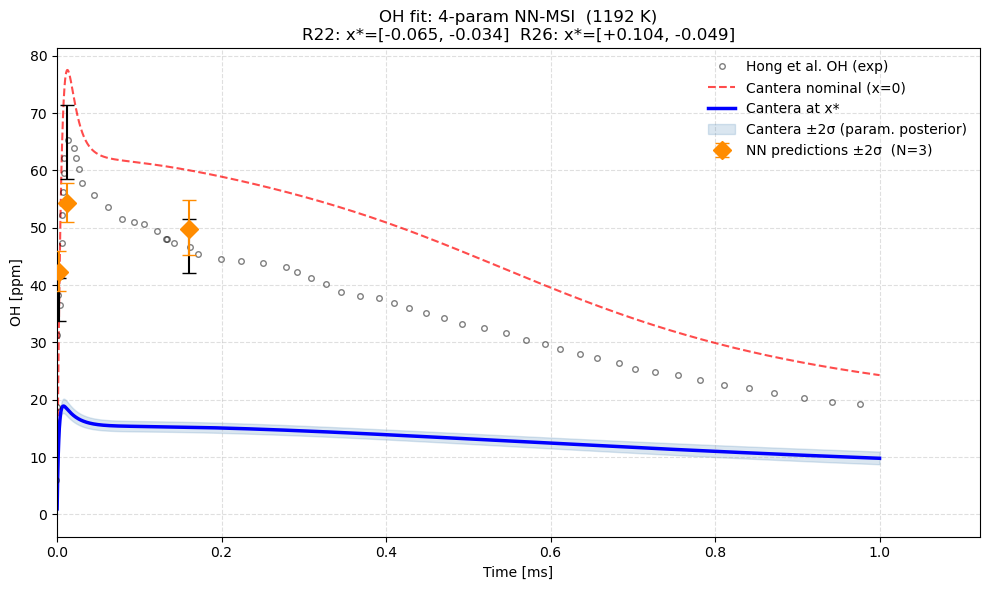

In [31]:
oh_xlim = max(t_oh_raw.max() * 1.15, 0.06)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_oh_raw, y_oh_raw, 'o', mfc='none', mec='k', ms=4, alpha=0.5,
        zorder=3, label='Hong et al. OH (exp)')
ax.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
            yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
            fmt='none', ecolor='k', elinewidth=1.5, capsize=5, zorder=4,
            label='_nolegend_')
ax.plot(T_OH * 1e3, oh_nom * 1e6, 'r--', lw=1.5, alpha=0.7,
        label='Cantera nominal (x=0)')
ax.plot(T_OH * 1e3, oh_opt * 1e6, 'b-',  lw=2.5,
        label='Cantera at x*')
ax.fill_between(T_OH * 1e3, oh_lower * 1e6, oh_upper * 1e6,
                color='steelblue', alpha=0.20,
                label='Cantera ±2σ (param. posterior)')
ax.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
            yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
            fmt='D', color='darkorange', ms=9, lw=1.5, capsize=5, zorder=7,
            label=f'NN predictions ±2σ  (N={N_TARGETS})')

ax.set_xlabel('Time [ms]')
ax.set_ylabel('OH [ppm]')
ax.set_xlim([0, oh_xlim])
ax.legend(loc='upper right', frameon=False)
ax.grid(True, ls='--', alpha=0.4)
ax.set_title(
    f'OH fit: 4-param NN-MSI  (1192 K)\n'
    f'R22: x*=[{x_opt[0]:+.3f}, {x_opt[1]:+.3f}]  '
    f'R26: x*=[{x_opt[2]:+.3f}, {x_opt[3]:+.3f}]')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_oh_fit.png', dpi=150)
print(f'Saved: {OUT_PREFIX}_oh_fit.png')


## Figure 2: H2O comparison

Saved: opt_1192k_oh_h2o_h2o_compare.png


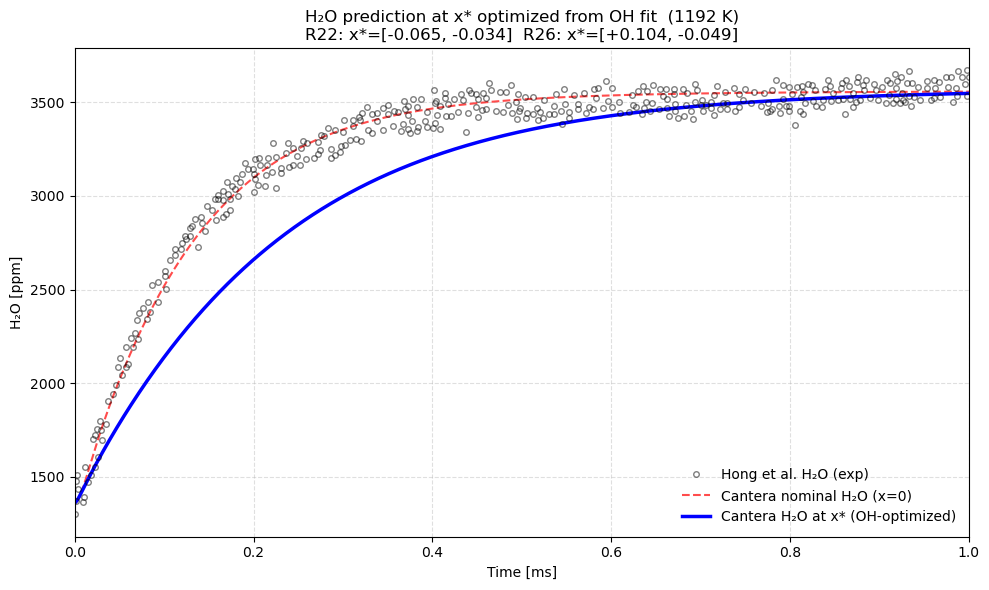

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_h2o_raw, y_h2o_raw, 'o', mfc='none', mec='k', ms=4, alpha=0.5,
        zorder=3, label='Hong et al. H₂O (exp)')
ax.plot(T_SIM * 1e3, h2o_nom * 1e6, 'r--', lw=1.5, alpha=0.7,
        label='Cantera nominal H₂O (x=0)')
ax.plot(T_SIM * 1e3, h2o_opt * 1e6, 'b-', lw=2.5,
        label='Cantera H₂O at x* (OH-optimized)')

ax.set_xlabel('Time [ms]')
ax.set_ylabel('H₂O [ppm]')
ax.set_xlim([0, 1.0])
ax.legend(loc='lower right', frameon=False)
ax.grid(True, ls='--', alpha=0.4)
ax.set_title(
    f'H₂O prediction at x* optimized from OH fit  (1192 K)\n'
    f'R22: x*=[{x_opt[0]:+.3f}, {x_opt[1]:+.3f}]  '
    f'R26: x*=[{x_opt[2]:+.3f}, {x_opt[3]:+.3f}]')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_h2o_compare.png', dpi=150)
print(f'Saved: {OUT_PREFIX}_h2o_compare.png')


## Figure 3: combined (2-panel)

Saved: opt_1192k_oh_h2o_combined.png

Done.


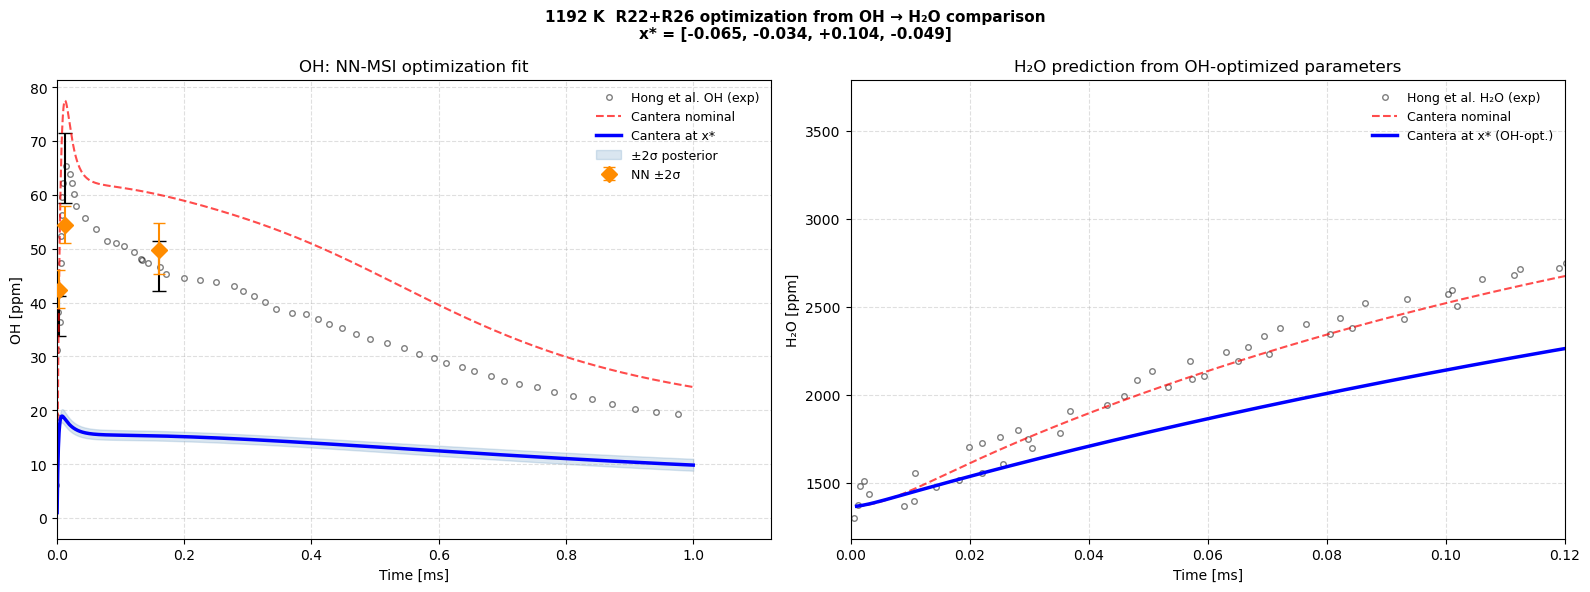

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# — OH panel —
ax1.plot(t_oh_raw, y_oh_raw, 'o', mfc='none', mec='k', ms=4, alpha=0.5,
         label='Hong et al. OH (exp)')
ax1.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
             yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
             fmt='none', ecolor='k', elinewidth=1.5, capsize=5,
             label='_nolegend_')
ax1.plot(T_OH * 1e3, oh_nom * 1e6, 'r--', lw=1.5, alpha=0.7,
         label='Cantera nominal')
ax1.plot(T_OH * 1e3, oh_opt * 1e6, 'b-', lw=2.5,
         label='Cantera at x*')
ax1.fill_between(T_OH * 1e3, oh_lower * 1e6, oh_upper * 1e6,
                 color='steelblue', alpha=0.20, label='±2σ posterior')
ax1.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
             yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
             fmt='D', color='darkorange', ms=8, lw=1.5, capsize=4, zorder=7,
             label='NN ±2σ')
ax1.set_xlabel('Time [ms]'); ax1.set_ylabel('OH [ppm]')
ax1.set_xlim([0, oh_xlim])
ax1.legend(frameon=False, fontsize=9)
ax1.grid(True, ls='--', alpha=0.4)
ax1.set_title('OH: NN-MSI optimization fit')

# — H2O panel —
ax2.plot(t_h2o_raw, y_h2o_raw, 'o', mfc='none', mec='k', ms=4, alpha=0.5,
         label='Hong et al. H₂O (exp)')
ax2.plot(T_SIM * 1e3, h2o_nom * 1e6, 'r--', lw=1.5, alpha=0.7,
         label='Cantera nominal')
ax2.plot(T_SIM * 1e3, h2o_opt * 1e6, 'b-', lw=2.5,
         label='Cantera at x* (OH-opt.)')
ax2.set_xlabel('Time [ms]'); ax2.set_ylabel('H₂O [ppm]')
ax2.set_xlim([0, 0.12])
ax2.legend(frameon=False, fontsize=9)
ax2.grid(True, ls='--', alpha=0.4)
ax2.set_title('H₂O prediction from OH-optimized parameters')

plt.suptitle(
    f'1192 K  R22+R26 optimization from OH → H₂O comparison\n'
    f'x* = [{x_opt[0]:+.3f}, {x_opt[1]:+.3f}, {x_opt[2]:+.3f}, {x_opt[3]:+.3f}]',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_combined.png', dpi=150, bbox_inches='tight')
print(f'Saved: {OUT_PREFIX}_combined.png')

print('\nDone.')
